⏰ TIME STEP ANALYSIS for Labeled Dataset(Feature 1)
Min time step: 1
Max time step: 49
Number of unique time steps: 49


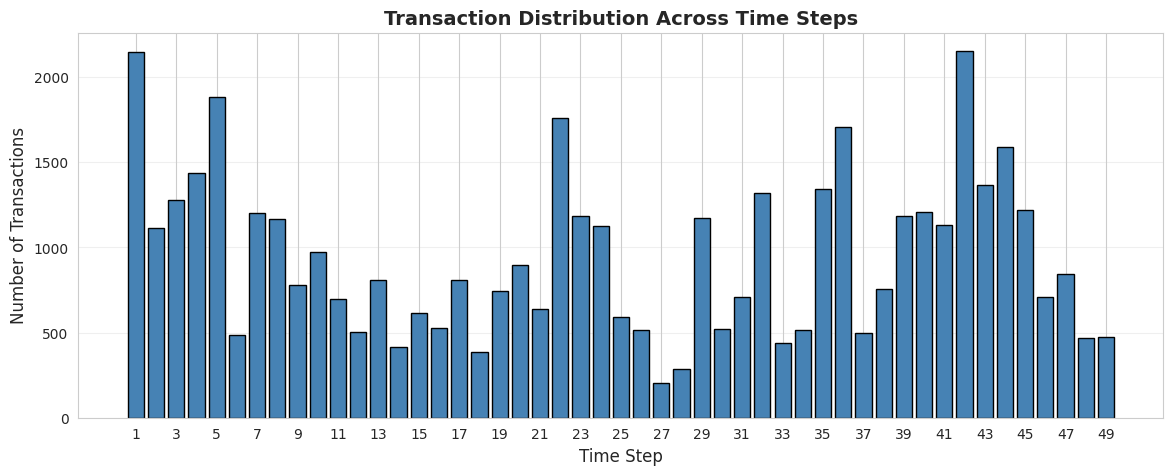


✂️ Splitting Train/Test Labeled Dataset by temporal split...
Train dataset shape: (37723, 168)
Test dataset shape: (8841, 168)

🎨 Creating temporal validation split...
✅ Validation splitting is done.


In [16]:
print("⏰ TIME STEP ANALYSIS for Labeled Dataset(Feature 1)")
print("="*60)

print(f"Min time step: {random_forest_df["time_step"].min()}")
print(f"Max time step: {random_forest_df["time_step"].max()}")
print(f"Number of unique time steps: {random_forest_df["time_step"].nunique()}")

# Transactions per time step
time_dist = random_forest_df["time_step"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(time_dist.index, time_dist.values, color='steelblue', edgecolor='black')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Transaction Distribution Across Time Steps', fontsize=14, fontweight='bold')
plt.xticks(range(1, 50, 2))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n✂️ Splitting Train/Test Labeled Dataset by temporal split...")
train_period_df = random_forest_df[random_forest_df["time_step"] <= 41].copy()
test_period_df = random_forest_df[random_forest_df["time_step"] >= 42].copy()
print(f"Train dataset shape: {train_period_df.shape}")
print(f"Test dataset shape: {test_period_df.shape}\n")

print("🎨 Creating temporal validation split...")
train_validation_df = train_period_df[train_period_df["time_step"] <= 34].copy()
validation_df = train_period_df[train_period_df["time_step"] >= 35].copy()
print("✅ Validation splitting is done.")


In [18]:
print("🛠️ Creating train, validation and test sets with separated features and labels")
feature_columns = [
    col for col in random_forest_df.columns
    if col not in ["txId", "time_step", "is_illicit"]
]

X_train_temporal = train_validation_df[feature_columns]
y_train_temporal = train_validation_df["is_illicit"]

X_val_temporal = validation_df[feature_columns]
y_val_temporal = validation_df["is_illicit"]

X_test_temporal = test_period_df[feature_columns]
y_test_temporal = test_period_df["is_illicit"]
print("✅ Done!")


🛠️ Creating train, validation and test sets with separated features and labels
✅ Done!


In [25]:
import random
from itertools import product 
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

print("🔎 Hyperparameter search\n")
rf_temporal_params = {
    "n_estimators": [450, 500, 550, 568, 600, 650],
    "max_depth": [15, 18, 20, 22, 25],
    "min_samples_split": [8, 10, 12, 15, 18],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [0.3, 0.5, "sqrt"]
}

# Produce a Cartesian product of all given iterables
print("✨ Creating all posibles variations of hyperparameters combinations\n")
param_combinations = list(
    product(
        rf_temporal_params["n_estimators"],
        rf_temporal_params["max_depth"],
        rf_temporal_params["min_samples_leaf"],
        rf_temporal_params["min_samples_split"],
        rf_temporal_params["max_features"],
    )
)

print("🎯 Selecting 30 random hyperparameters combinations")
# Select 30 random sets of hyperparameters
random.seed(42)
selected_params = random.sample(param_combinations, 30)

🔎 Hyperparameter search

✨ Creating all posibles variations of hyperparameters combinations

🎯 Selecting 30 random hyperparameters combinations


In [26]:
print("📚 Training pipeline")
results = []

for params in selected_params:
    #Tuple unpacking
    (
        n_estimators,
        max_depth,
        min_samples_leaf,
        min_samples_split,
        max_features
    ) = params
    
    # pipeline
    model = ImbPipeline([
        (
            "smote", SMOTE(random_state=42) 
        ),
        (
            "model", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    #Fitting on the pipeline
    model.fit(X_train_temporal, y_train_temporal)
    
    # Validation
    val_probs = model.predict_proba(X_val_temporal)[:, 1]
    score = roc_auc_score(y_val_temporal, val_probs)

    results.append(
        {
            "n_estimators": n_estimators,
            "max_depth": max_depth, 
            "min_samples_leaf": min_samples_leaf,
            "min_samples_split": min_samples_split,
            "max_features": max_features,
            "roc_auc": score
        }
    )

temporal_results = (
    pd.DataFrame(results).sort_values("roc_auc", ascending=False)
)
print(temporal_results.head())

📚 Training pipeline
    n_estimators  max_depth  min_samples_leaf  min_samples_split max_features  \
16           450         18                 1                 10         sqrt   
18           450         22                 1                 15         sqrt   
20           500         20                 4                 15         sqrt   
25           500         18                 4                  8         sqrt   
26           600         25                 2                 15         sqrt   

     roc_auc  
16  0.981119  
18  0.981104  
20  0.981076  
25  0.981072  
26  0.981066  


In [29]:
print("Model training with random-split best hyperparameters but temporal split data")
rf_exp2b_model = ImbPipeline([
    (
        "smote", SMOTE(random_state=42)
    ),
    (
        "model", RandomForestClassifier(
            n_estimators=568,
            max_depth=20,
            min_samples_leaf=2,
            min_samples_split=12,
            max_features=0.3,
            random_state=42,
            n_jobs=-1
        )
    )
])

# Training on full historical training period:
rf_exp2b_model.fit(
    train_period_df[feature_columns],
    train_period_df["is_illicit"]
)

exp2b_probs = rf_exp2b_model.predict_proba(X_test_temporal)[:, 1]
exp2b_preds = rf_exp2b_model.predict(X_test_temporal)

print("ROC-AUC:", roc_auc_score(y_test_temporal, exp2b_probs))
print("PR-AUC :", average_precision_score(y_test_temporal, exp2b_probs))
print("Recall :", recall_score(y_test_temporal, exp2b_preds))
print("F1     :", f1_score(y_test_temporal, exp2b_preds))

Model training with random-split best hyperparameters but temporal split data
ROC-AUC: 0.9594764266432293
PR-AUC : 0.7047133600337356
Recall : 0.47794117647058826
F1     : 0.6331168831168831
